In [1]:
# suppress tensorflow logging, usually not useful unless you are having problems with tensorflow or accessing gpu
# it seems necessary to have this environment variable set before tensorflow is imported, or else it doesn't take effect
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 

# imports generally useful throughout the notebook
# usually all imports should happen at the top of a notebook, but in
# these notebooks where the purpose is to show how to use the Keras API
# the relevant imports will happen in the cells where the API is discussed
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# global settings for notebook output and images
plt.rcParams['figure.figsize'] = (8, 8) # set default figure size, 10in by 8in
np.set_printoptions(precision=4, suppress=True)

In [2]:
# import project defined modules / functions used in this notebook
# ensure that the src directory where project modules are found is on
# the PYTHONPATH
import sys
sys.path.append("../src")

# assignment function imports for doctests and github autograding
# these are required for assignment autograding
from nndl import vectorize_samples, plot_history

In [3]:
# if want to restrict to cpu or gpu, configure visible device for rest of notebook to use
#dev = tf.config.list_physical_devices()
#print('Available Devices : ', dev)
#tf.config.set_visible_devices(dev[0], 'CPU')
#tf.config.set_visible_devices(dev[1], 'GPU')

# Chapter 4: Getting Started with Neural Networks: Classification and Regression

Supporting materials for:

Chollet (2021). *Deep Learning with Python*. 2nd ed. Manning Publications Co.
[Amazon](https://www.amazon.com/Learning-Python-Second-Fran%C3%A7ois-Chollet/dp/1617296864/ref=sr_1_1?crid=32NFM2SBCJVQQ)

The examples from this chapter show some basic end-to-end machine learning workflows.  We introduce data preprocessing,
basic model architecture principles, and model evaluation.

There are examples of classification and regression problems.  Make sure you understand the fundamental difference.
A classification problem is when we try to predict a label.  For example, the simpliest classification is binary
classification.  We will predict movie reviews where the class label of the review was either positive or negative,
this is a binary classification problem.  Classification can be more complex.  We have already seen
examples of multiclass classification with the MNIST training set.  In that case, we are trying to predict which of
10 digits each image belongs to.  This is an example of multiclass classification.

A regression problem then is one where we are trying to predict a continuous value.  A good example is predicting house
prices from house features, which we have also seen examples of so far in this class.



# 4.2 Classifying newswires: A multiclass classification example.

When we have more than 2 (binary) classes, we will be doing **multiclass classification**.  More specificaly this is known
as **single-label multiclass classification**.

## 4.2.1 The Reuters dataset

This dataset is also textual.  It consists of news articles.  The label we are trying to predict from the text
is the topic or area of the news article.  There are 46 different topics, like finance, sports, politics), etc.
Unlike the movie reviews, the topics are not evenly represented in this dataset, some have more example
samples than others.  This type of skewed representation can be a problem when trying to train a classification
model.

The Reuters dataset is another one of hte example datasets available from the `keras.datasets` module.

Loading the Reuters dataset.

In [4]:
from tensorflow.keras.datasets import reuters

(train_data, train_labels), (test_data, test_labels) = reuters.load_data(num_words=10000)

In [5]:
# there are 8,982 training examples and 2,246 test examples
print(train_data.shape)
print(test_data.shape)

(8982,)
(2246,)


As with the IMDB reviews, each sample is a (regular python) list of integers, which are word indices of a word dictionary for the
articles.

In [6]:
article_no = 1234
print(train_data[article_no])
print(len(train_data[article_no]))

[1, 4, 37, 38, 2047, 693, 182, 9, 25, 356, 8, 77, 33, 941, 10, 109, 29, 2014, 5, 195, 2224, 494, 3427, 364, 6, 658, 4, 182, 95, 216, 6, 2842, 1997, 77, 8, 77, 33, 3214, 4, 37, 38, 141, 66, 259, 2930, 1594, 24, 3270, 33, 57, 7226, 4249, 13, 234, 201, 9, 822, 4, 143, 188, 29, 3737, 364, 625, 31, 127, 973, 2088, 52, 1489, 9, 4, 2930, 530, 5236, 195, 490, 21, 4, 168, 642, 5, 25, 3270, 4, 2047, 693, 182, 5, 4, 214, 212, 9, 4, 214, 5551, 356, 8, 7, 241, 24, 1282, 693, 34, 325, 4923, 4, 260, 76, 9, 670, 2939, 62, 834, 6, 2842, 4, 3579, 1260, 490, 23, 6, 2026, 27, 429, 258, 552, 6, 5313, 4, 3427, 364, 17, 12]
134


Here is how you can decode it back to words again.

In [7]:
word_index = reuters.get_word_index()

reverse_word_index = dict(
    [(value, key) for (key, value) in word_index.items()]
)

decoded_newswire = " ".join(
    [reverse_word_index.get(i - 3, "?") for i in train_data[article_no]]
)

print(decoded_newswire)

? the u s specialty steel industry and its union said they will seek a three year extension of president reagan's import restraint program to give the industry more time to restore competitiveness they said they will tell the u s international trade commission itc thursday that termination will have disastrous consequences for american companies and workers the current four year voluntary program reached with foreign exporters ends this summer and the itc must advise president reagan on the economic effect of its termination the specialty steel industry of the united states and the united steelworkers union said in statement that imported steel was still flooding the domestic market and continued curbs were needed to restore the industry's health reagan is to decide by july 19 whether to renew the restraint program reuter 3


The label is an integer between 0 and 45, a topic index.  Here are the labels for the first 10 training samples.

In [8]:
train_labels[:10]

array([ 3,  4,  3,  4,  4,  4,  4,  3,  3, 16])

There is also an list of the label/category names for this dataset.

In [9]:
label_names = reuters.get_label_names()
print(label_names)
print(label_names[4])

('cocoa', 'grain', 'veg-oil', 'earn', 'acq', 'wheat', 'copper', 'housing', 'money-supply', 'coffee', 'sugar', 'trade', 'reserves', 'ship', 'cotton', 'carcass', 'crude', 'nat-gas', 'cpi', 'money-fx', 'interest', 'gnp', 'meal-feed', 'alum', 'oilseed', 'gold', 'tin', 'strategic-metal', 'livestock', 'retail', 'ipi', 'iron-steel', 'rubber', 'heat', 'jobs', 'lei', 'bop', 'zinc', 'orange', 'pet-chem', 'dlr', 'gas', 'silver', 'wpi', 'hog', 'lead')
acq


## 4.2.2 Preparing the data

You can vectorize the data with the exact same code as in previous example.  Recall we are using what is
known as **multi-hot encoding** to transform the word lists of different sizes into a 10,000 sized
vector.

**Note**: We have put function that are reused in notebooks in the `src/nndl.py` module file and import them to reuse them.

Encoding the input data.

In [10]:
x_train = vectorize_samples(train_data)
x_test = vectorize_samples(test_data)

print(x_train.shape)
print(x_test.shape)

(8982, 10000)
(2246, 10000)


There are two ways to vectorize the labels.  We can cast the label list as an integer tensor.  Or we can use
**one-hot encoding**.  One-hot encoding is a widely used format for categorical data, it is also sometimes
called **categorical encoding**.  In this case, one-hot encoding of the labels consists of embedding each label
as an all-zero vector with a 1 in the place of the correct label index.

**Note**: The difference between one-hot encoding and multi-hot encoding, as you may realize, is that on-hot
encodes a single category, so only one of the 46 categories will have a 1 in the resulting label
vector for this dataset.

Encoding the labels.

In [11]:
def to_one_hot(labels, dimension=46):
    """A hand-made implementaiton of one-hot
    encoding.  Given integer labels, reencode as one-hot
    encoded vector.  We assume 46 dimensions of the
    reuters output category labels.  The resulting shape
    of the labels is (num_samples, 46) where each of the
    46 features is a 0 or 1 value, and only one value is 
    encoded as 1, which is the correct category for that sample.

    Arguments
    ---------
    labels - The labels for a set of data, e.g. y_train, a 1-D vector currently encoded
      as an integer with range 0-(dimension-1)
    dimension - The number of categories.  Default of 46 for the reuters
      dataset, though we could infer this from the input labels if needed

    Returns
    -------
    one_hot_encoded_labels - The category is encoded as a #dimension vector, with a
      1 in the correct category label position, and 0 in all other positions.
    """
    # create resulting one-hot encoded labels, initialized to all 0's
    # initially
    one_hot_encoded_labels = np.zeros((len(labels), dimension))
    
    for sample_num, label in enumerate(labels):
        one_hot_encoded_labels[sample_num, label] = 1.0
    return one_hot_encoded_labels

# one-hot encode the train and test labels
y_train = to_one_hot(train_labels)
y_test = to_one_hot(test_labels)

print(y_train.shape)
print(y_train[0])
print(train_labels[0])

(8982, 46)
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
3


We don't really need to write encodings like this by hand.  Usually libraries like
`scikit-learn` and `tensorflow.keras` will have premade functions for common tasks
like this.

In [12]:
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

print(y_train.shape)
print(y_train[0])
print(train_labels[0])

(8982, 46)
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
3


## 4.2.3 Building your model

The news article classification problem is similar to our first binary classification problem.  The input is encoded in the
same way.

But the number of outputs has changed from 1 binary label of 0 or 1, to 46 outputs of 0 or 1, where only 1 of the 46 should be 1
to indicate the predicted category of the news article.

A 16-dimensional space may be too limited to separate 46 different classes.  Such small layers act as information bottlenecks.
(Which can be bad, but can also be good.  e.g. if overfitting, actually making more of a bottleneck can be one way to fight the overfitting and nudge the network to try not to learn unimportant noise of the training data.)

For this reason, we may anticipate we need to use larger layers.

Model definition.

In [13]:
model = keras.Sequential([
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(46, activation="softmax")
])

Notice we end the model with a `Dense` layer with 46 dimensions/outputs this time (one for each one-hot
encoded output we want to predict).

Second we use `softmax` activation for the final output layer.  `softmax` activation outputs
a **probability distribution** over the 46 different output classes.  For each sample, the model
produces a 46-dimensional output vector, where the `output[i]` is the probability that the sample 
belongs to class `i`.  Since this is a probability distribution, the 46 scores will sum up to 1,
this is part of what `softmax` does (and you might better understand your by-hand implementation
of `softmax` from seeing how it is used here).

The best loss function to use is probably `categorical_crossentropy`.  As the name implies this loss
is good for categorical (multiclass) outputs.

Compiling the model.

In [14]:
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

I0000 00:00:1749072271.494639   89710 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9706 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


## 4.2.4 Validating your approach

Lets again split off some of the training data to use for validation while fitting the model.

Setting aside a validation set.

In [15]:
x_val = x_train[:1000]
partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

print(x_val.shape)
print(partial_x_train.shape)

(1000, 10000)
(7982, 10000)


Now we will train for 20 epochs, using batchs of 512 samples.

In [16]:
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20


I0000 00:00:1749072314.293327   91711 service.cc:152] XLA service 0x733470016130 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1749072314.293783   91711 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3060, Compute Capability 8.6
2025-06-04 21:25:14.340153: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1749072314.485614   91711 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-06-04 21:25:16.525814: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 280 bytes spill stores, 280 bytes spill loads

2025-06-04 21:25:16.702038: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_213'

11/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.2759 - loss: 3.4375

I0000 00:00:1749072320.703786   91711 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
2025-06-04 21:25:22.761836: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 88 bytes spill stores, 88 bytes spill loads

2025-06-04 21:25:23.325606: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 124 bytes spill stores, 124 bytes spill loads

2025-06-04 21:25:23.673711: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 292 bytes spill stores, 292 bytes spill loads

2025-06-04 21:25:24.640336: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Re

16/16 ━━━━━━━━━━━━━━━━━━━━ 19s 765ms/step - accuracy: 0.3314 - loss: 3.2254 - val_accuracy: 0.5570 - val_loss: 1.9084
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.6075 - loss: 1.7346 - val_accuracy: 0.6820 - val_loss: 1.4095
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7224 - loss: 1.2745 - val_accuracy: 0.7280 - val_loss: 1.1926
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.7840 - loss: 1.0082 - val_accuracy: 0.7650 - val_loss: 1.0782
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8252 - loss: 0.8203 - val_accuracy: 0.7780 - val_loss: 1.0091
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8445 - loss: 0.7091 - val_accuracy: 0.7870 - val_loss: 0.9615
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8701 - loss: 0.5793 - val_accuracy: 0.7800 - val_loss: 0.9625
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ -1s -80732us/step - accuracy: 0.8944 - loss: 0.4862 - val_accuracy: 0.8050 - val_l

And finally let's display the loss and accuracy curves again.  

**Note**: again we are reusing functions we have previously defined and discussed here to plot the
loss and accuracy curves from the training run.

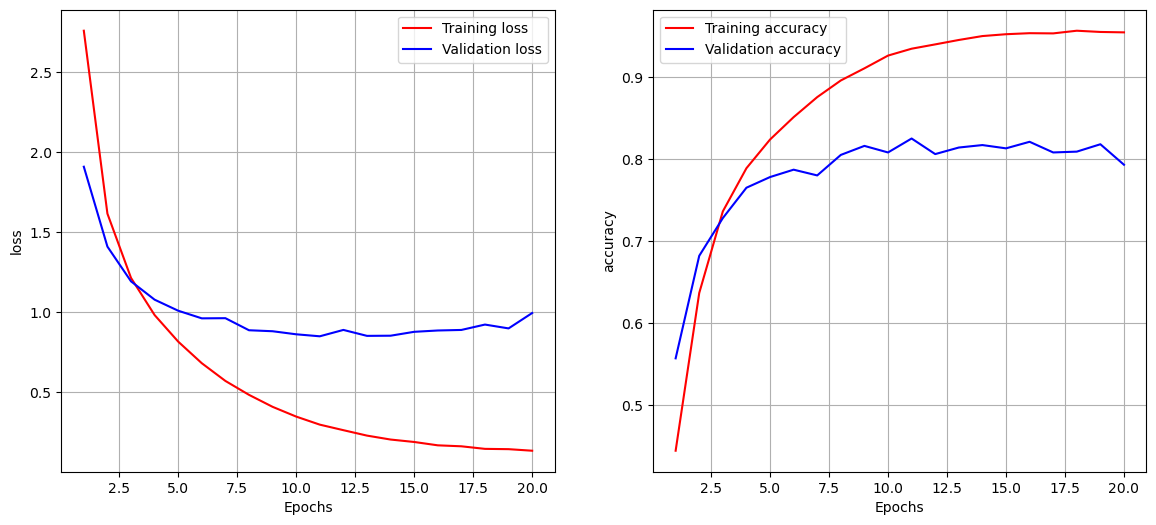

In [17]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model begins to overfit after 8 or 9 epochs, topping out at about just above 80% accuracy.  How can you tell?
Looking at the training loss curves, you can see that the validation loss history usually decreases
till about epoch 9 (you might see some variation because this is stochastic gradient batch, so samples
are drawn in random order for training).  Similarly you can see that usually accuracy tops out at about
that number of epochs as well.

As before, we take a brute force method to avoid overfitting, and just retrain from
scratch and stopping before we saw the overfitting.

Retraining a model from scratch and stopping before overfitting.

In [18]:
# create the same model from scratch
model = keras.Sequential([
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(46, activation="softmax")
])


# compile model with same loss and optimizer
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# fit model stopping after 9 epochs of training
model.fit(x_train,
          y_train,
          epochs=10,
          batch_size=512)

# jump to directly evaluating results on the test data of this model
results = model.evaluate(x_test, y_test)
print(results)

2025-06-04 21:27:56.795739: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 359280000 exceeds 10% of free system memory.
2025-06-04 21:27:57.658555: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 359280000 exceeds 10% of free system memory.


Epoch 1/10
16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.3083 - loss: 3.4162

2025-06-04 21:28:01.752436: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 32 bytes spill stores, 32 bytes spill loads

2025-06-04 21:28:02.357887: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 32 bytes spill stores, 32 bytes spill loads

2025-06-04 21:28:02.402102: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 124 bytes spill stores, 124 bytes spill loads

2025-06-04 21:28:02.970726: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_239', 296 bytes spill stores, 296 bytes spill loads

2025-06-04 21:28:03.053973: I external/l

18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 426ms/step - accuracy: 0.3329 - loss: 3.3374
Epoch 2/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6541 - loss: 1.7810
Epoch 3/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7255 - loss: 1.2581
Epoch 4/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7950 - loss: 0.9778
Epoch 5/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8293 - loss: 0.8199
Epoch 6/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8613 - loss: 0.6694
Epoch 7/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8845 - loss: 0.5572
Epoch 8/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9072 - loss: 0.4645
Epoch 9/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9160 - loss: 0.3957
Epoch 10/10
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9295 - loss: 0.3445


2025-06-04 21:28:10.316004: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_68', 4 bytes spill stores, 4 bytes spill loads



60/71 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8038 - loss: 0.8912

2025-06-04 21:28:11.246967: I external/local_xla/xla/stream_executor/cuda/subprocess_compilation.cc:346] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_61', 8 bytes spill stores, 8 bytes spill loads



71/71 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.8025 - loss: 0.8950
[0.9250019788742065, 0.7934104800224304]


This approach will usually reach an accuracy of about 80% on the test data set, the data that was neither
seen by the gradient descent for adjusting the weights, nor used to evaluate the loss after each
epoch.

This is more impressive than before, though you may not realize it at first. 
With a balanced binary classification, the accuracy of purely random
guessing would be 50%.  But here random guessing only achieves `1 / 46 =` about 2% accuracy.

It is always a good idea to have in mind the performance of a random baseline.  We can
create such a random baseline and check empirically:


In [19]:
import copy

# copy and randomly shuffle up the labels.  This better simulates random guessing here,
# which ends up higher than 1/46 because the labels are not evenly distributed in this
# test data
test_labels_copy = copy.copy(test_labels)
np.random.shuffle(test_labels_copy)

# count up number of times the random guess/shuffle gets answer correct
hits_array = np.array(test_labels) == np.array(test_labels_copy)

hits_array.mean()

0.18655387355298308

So actually, unlike what I just said above, a better random guesser would get about 18% accuracy.  This random
basiline is a better guesser because, the categories are not equally distributed.  So the random guesser should guess
the larger categories more frequently than the smaller represented news article categories.  Using a random shuffle
maintains the frequency of the categories, and thus acts as a random guesser biased to guess at the same frequency
of the category labels.

In any case, a model getting 80% here is still better than you might have initially thought, given the problem is much
tougher here than before.

## 4.2.5 Generating predictions on new data

Calling `predict` with a trained model on new samples returns a class probability ditribution over all 46 topics.  

We can generate topic predictions for all of the test data.

In [20]:
predictions = model.predict(x_test)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step


Each entry in `predictions` is a vector of length 46 that sums up to 1.0.  You can think of the value as the probability that
the test sample article is one of each of the 46 topic categories.

In [21]:
predictions[0].shape

(46,)

In [22]:
print(predictions[0])
print(np.sum(predictions[0]))
print(y_test[0])
print(test_labels[0])

[0.     0.0001 0.     0.5343 0.4471 0.     0.     0.0001 0.0069 0.
 0.     0.0001 0.0001 0.0004 0.     0.     0.0045 0.0012 0.     0.0021
 0.0013 0.0002 0.     0.     0.     0.0001 0.     0.     0.0002 0.0001
 0.     0.0001 0.     0.     0.0001 0.     0.0004 0.     0.     0.0003
 0.0001 0.     0.     0.     0.     0.    ]
1.0000001
[0. 0. 0. 1. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.
 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
3


The largest entry should be chosen as the predicted class.  As should usually be the case, you should see that topic 3 has the
largest predicted value, around 0.73, and thus topic 3 would be the predicted topic for the test article 0.

We can use `np.argmax()` to convert the one-hot encoding back to an integer topic index.

In [23]:
np.argmax(predictions[0])

3

## 4.2.6 A different way to handle the labels and the loss

We mentioned that the labels could also be cast as an integer tensor.  So for example if we just copy the original labels, we end up with
train and test label arrays that look like this:

In [24]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

print(y_train.shape)
print(y_train)

(8982,)
[ 3  4  3 ... 25  3 25]


The only thing this approach would change is the choice of the loss function.  The loss function `categorical_crossentropy`
expects the labels to follow a categorical encoding.  With integer labels you should use `sparse_categorical_crossentropy`

For completeness, lets see if this integer encoding of the category improves performance.

In [25]:
# lets show complete example of using integer encoding and this different loss function.
# build model from scratch
model = keras.Sequential([
            layers.Dense(64, activation="relu"),
            layers.Dense(64, activation="relu"),
            layers.Dense(46, activation="softmax")
])

# compile model specifying this different loss function
model.compile(optimizer="rmsprop",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# we have different y data labels, so pull out validation data again
#x_val = x_train[:1000]
#partial_x_train = x_train[1000:]
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

# fit the model
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=512,
                    validation_data=(x_val, y_val))

Epoch 1/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 226ms/step - accuracy: 0.4206 - loss: 3.0836 - val_accuracy: 0.6110 - val_loss: 1.7468
Epoch 2/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6587 - loss: 1.5811 - val_accuracy: 0.6860 - val_loss: 1.3706
Epoch 3/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.7302 - loss: 1.2048 - val_accuracy: 0.7220 - val_loss: 1.1986
Epoch 4/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.7900 - loss: 0.9402 - val_accuracy: 0.7550 - val_loss: 1.0887
Epoch 5/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8224 - loss: 0.7908 - val_accuracy: 0.7730 - val_loss: 1.0090
Epoch 6/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8543 - loss: 0.6563 - val_accuracy: 0.7800 - val_loss: 0.9680
Epoch 7/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.8844 - loss: 0.5478 - val_accuracy: 0.7940 - val_loss: 0.9205
Epoch 8/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9085 - loss: 0.4471 - val_accuracy: 0.8180 - 

2025-06-04 21:34:01.846186: W tensorflow/core/kernels/data/prefetch_autotuner.cc:52] Prefetch autotuner tried to allocate 20484096 bytes after encountering the first element of size 20484096 bytes.This already causes the autotune ram budget to be exceeded. To stay within the ram budget, either increase the ram budget or reduce element size


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9529 - loss: 0.1904 - val_accuracy: 0.8080 - val_loss: 0.9094
Epoch 15/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9516 - loss: 0.1856 - val_accuracy: 0.8170 - val_loss: 0.8996
Epoch 16/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9542 - loss: 0.1622 - val_accuracy: 0.8180 - val_loss: 0.9176
Epoch 17/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.9612 - loss: 0.1350 - val_accuracy: 0.8160 - val_loss: 0.9129
Epoch 18/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.9628 - loss: 0.1300 - val_accuracy: 0.8120 - val_loss: 0.9589
Epoch 19/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9580 - loss: 0.1365 - val_accuracy: 0.8200 - val_loss: 0.9392
Epoch 20/20
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.9655 - loss: 0.1133 - val_accuracy: 0.8070 - val_loss: 0.9937


The new loss function is still mathematically the same as `categorical_crossentropy`, it just has
a different interface.  Results from train are about the same here.

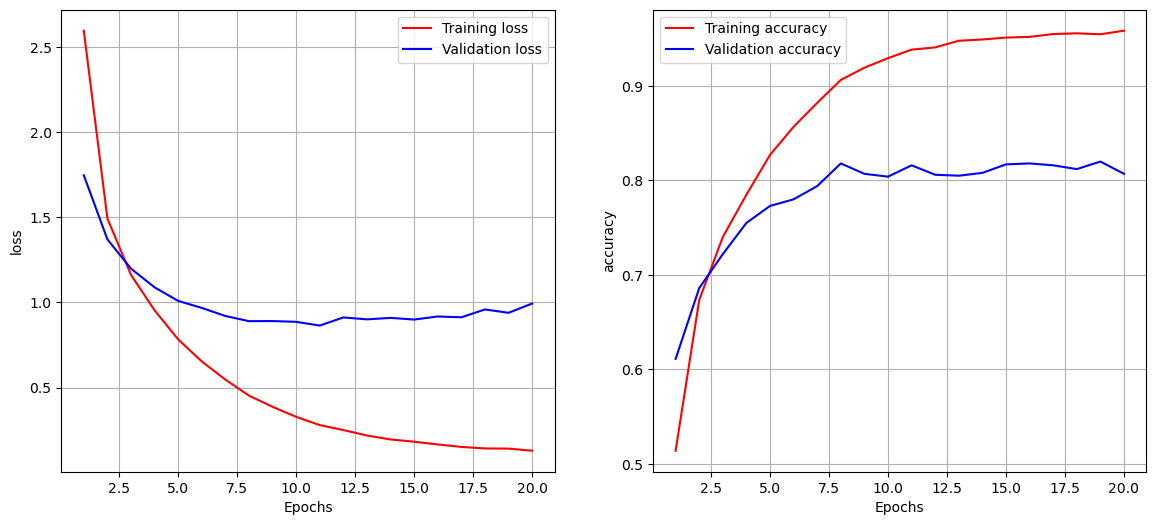

In [26]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

In [27]:
results = model.evaluate(x_test, y_test)
print(results)

71/71 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7965 - loss: 0.9995
[1.0579125881195068, 0.7880676984786987]


## 4.2.7 The importance of having sufficiently large intermediate layers

We mentioned earlier that because the final outputs are 46-dimensional, you should
avoid intermediate layers with many fewer than 46 units. Now let’s see what happens
when we introduce an information bottleneck by having intermediate layers that are
significantly less than 46-dimensional: for example, 4-dimensional.

A model with an information bottleneck.

In [28]:
# lets first revert back to one-hot categorical encoded labels and using categorical_crossentropy
y_train = to_categorical(train_labels)
y_test = to_categorical(test_labels)

# also resplit the validation data again
y_val = y_train[:1000]
partial_y_train = y_train[1000:]

In [29]:
# create model with a bottleneck
model = keras.Sequential([
            layers.Dense(64, activation="relu"),
            layers.Dense(4, activation="relu"),
            layers.Dense(46, activation="softmax")
])

# back to categorical_crossentropy for the categorical encoding
model.compile(optimizer="rmsprop",
              loss="categorical_crossentropy",
              metrics=["accuracy"])

# fit the model
history = model.fit(partial_x_train,
                    partial_y_train,
                    epochs=20,
                    batch_size=128,
                    validation_data=(x_val, y_val))

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 8s 65ms/step - accuracy: 0.3284 - loss: 3.2428 - val_accuracy: 0.4160 - val_loss: 2.1095
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5147 - loss: 1.9044 - val_accuracy: 0.5870 - val_loss: 1.5806
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6070 - loss: 1.4592 - val_accuracy: 0.6350 - val_loss: 1.4330
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7096 - loss: 1.2093 - val_accuracy: 0.6700 - val_loss: 1.3568
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7373 - loss: 1.0695 - val_accuracy: 0.6980 - val_loss: 1.2953
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7523 - loss: 0.9814 - val_accuracy: 0.6890 - val_loss: 1.2775
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7694 - loss: 0.8725 - val_accuracy: 0.7030 - val_loss: 1.2475
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7630 - loss: 0.8498 - val_accuracy: 0.6950 - val_loss

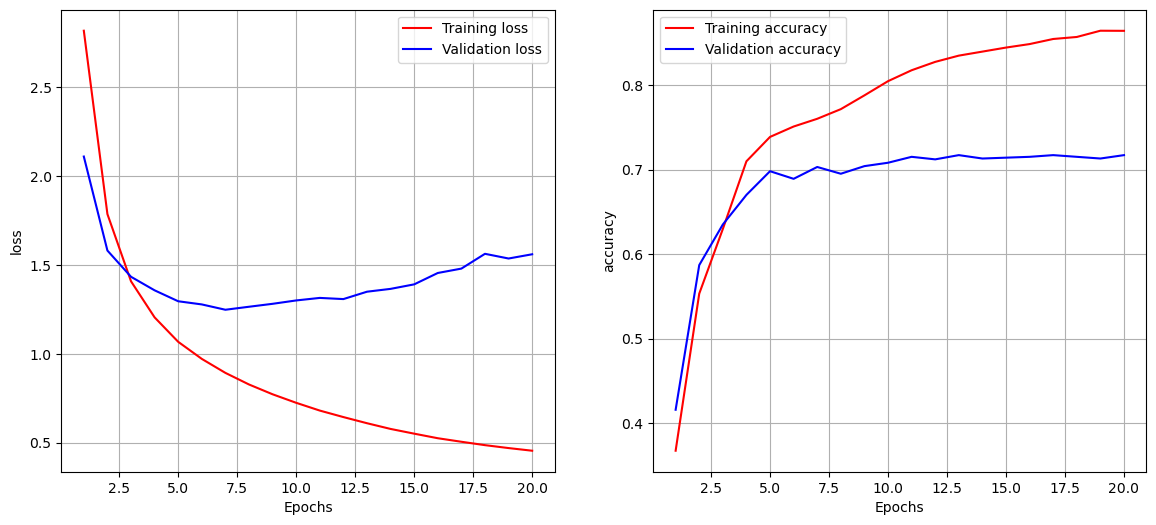

In [30]:
plt.figure(figsize=(14,6))
ax_loss = plt.subplot(1, 2, 1)
plot_history(ax_loss, history.history, 'loss')
ax_acc = plt.subplot(1, 2, 2)
plot_history(ax_acc, history.history, 'accuracy')

The model shows that the best validation accuracy is around 70%, an 8-10% drop.  This is mostly due
to fact we are compressing a lot of information into an intermediate space that is too low-dimensional.

Notice that the accuracy is continuing to go up on the validation data (usually).  However usually
when I run, the validation loss does stop decreasing around epoch 9 or 10, indicating that probably
the model is overfitting after this point, just like before.

## 4.2.8 Further Experiments

Left as an exercise for the student.  Try and improve the performance of this multiclass classification model.  Try the following

- Try using larger or smaller layers.
- Try using more or less intermediate layers.

## 4.2.9 Wrapping up

<font color='blue'>

What you should remember from this example of multiclass classification using a neural network.

- If classifying among N classes (multiclass classification), should end with a `Dense` layers of size N
- For single-label multiclass classification, us a `softmax` activation to get a probability distribution over the N output classes.
- Categorical crossentropy is usual loss function for such problems.
- Two ways to handle labels
  - Encode via categorical encoding (one-hot encoding) and use `categorical_crossentropy` loss function.
  - Encode labels as integers and use `sparse_categorical_crossentropy` loss function.
- If you need to classify data into a large number of categories, avoid information bottlenecks in your model layers.


Also as we saw above, if using integer labels, you actually still need a N sized `softmax` output layer.  The crossentropy
loss computes loss between the category and the N sized probability distribution.  Apparently even though the
labels in the second example are integers in the range 0-45, `keras` does the right thing in the last layer to compute
the loss.  If we converted the last layer to a single output and used no activation, we would then be performing
an regression model.